In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("jena_climate_2009_2016.csv.zip")

In [3]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
df.isnull().sum()

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), str(1)
memory usage: 55.7 MB


In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


In [7]:
df.rename(columns = {"Date Time" : "Date_Time"}, inplace=True)
df['Date_Time'] = pd.to_datetime(df['Date_Time'] , format = '%d.%m.%Y %H:%M:%S')
df = df.set_index("Date_Time")

In [8]:
df.shape

(420551, 14)

In [9]:
"""This is Python slicing.
General format:
df[start:end:step]"""
# every 6th row = 1 record per hour
#since the data is for every ten minutes taking 6 steps makes data hourly so
df = df[::6]
print("Shape of Dataset after downgrade: ",df.shape)

Shape of Dataset after downgrade:  (70092, 14)


In [10]:
target_col = "T (degC)"
features = df.columns.to_list()

In [11]:
n = len(df)
train_end = int(n * 0.70)   # 70% train
val_end   = int(n * 0.85) 

In [12]:
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

In [13]:
print(f"Train: {train_df.index[0]}  →  {train_df.index[-1]}  ({len(train_df)} rows)")
print(f"Val  : {val_df.index[0]}  →  {val_df.index[-1]}  ({len(val_df)} rows)")
print(f"Test : {test_df.index[0]}  →  {test_df.index[-1]}  ({len(test_df)} rows)")

Train: 2009-01-01 00:10:00  →  2014-08-05 01:20:00  (49064 rows)
Val  : 2014-08-05 02:20:00  →  2015-10-17 19:10:00  (10514 rows)
Test : 2015-10-17 20:10:00  →  2016-12-31 23:20:00  (10514 rows)


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features])
val_scaled   = scaler.transform(val_df[features])
test_scaled  = scaler.transform(test_df[features])

In [19]:
seq_len = 24
target_idx = features.index(target_col)

def create_sequences(data , seq_len , target_idx):
    X , y = [] , []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])           # all 14 features
        y.append(data[i + seq_len, target_idx])   # next step temperature
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, seq_len, target_idx)
X_val,   y_val   = create_sequences(val_scaled,   seq_len, target_idx)
X_test,  y_test  = create_sequences(test_scaled,  seq_len, target_idx)



In [20]:
print("X_train:", X_train.shape)   # (N, 24, 14)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (49040, 24, 14)
X_val  : (10490, 24, 14)
X_test : (10490, 24, 14)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

model = Sequential([
    LSTM(64, input_shape=(seq_len, len(features)), return_sequences=False),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.summary()

# Callbacks to save the best model by validation loss and allow early stopping
checkpoint = ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True, verbose=1)
earlystop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[checkpoint, earlystop]
)

# Also save the final model
model.save("final_model.h5")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

...


Epoch 4: finished saving model to best_model.h5
767/767 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 2.1562e-04 - val_loss: 4.3685e-04
Epoch 5/10
767/767 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0040e-04
Epoch 5: val_loss improved from 0.00044 to 0.00031, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.9839e-04 - val_loss: 3.1325e-04
Epoch 6/10
765/767 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9117e-04
Epoch 6: val_loss did not improve from 0.00031
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.9008e-04 - val_loss: 3.6845e-04
Epoch 7/10
760/767 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8439e-04
Epoch 7: val_loss improved from 0.00031 to 0.00030, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.8111e-04 - val_loss: 3.0082e-04
Epoch 8/10
762/767 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8133e-04
Epoch 8: val_loss improved from 0.00030 to 0.00024, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 1.8076e-04 - val_loss: 2.4441e-04
Epoch 9/10
766/767 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7116e-04
Epoch 9: val_loss did not improve from 0.00024
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 1.7353e-04 - val_loss: 2.5101e-04
Epoch 10/10
762/767 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7989e-04
Epoch 10: val_loss improved from 0.00024 to 0.00023, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.7511e-04 - val_loss: 2.2503e-04
Restoring model weights from the end of the best epoch: 10.


328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


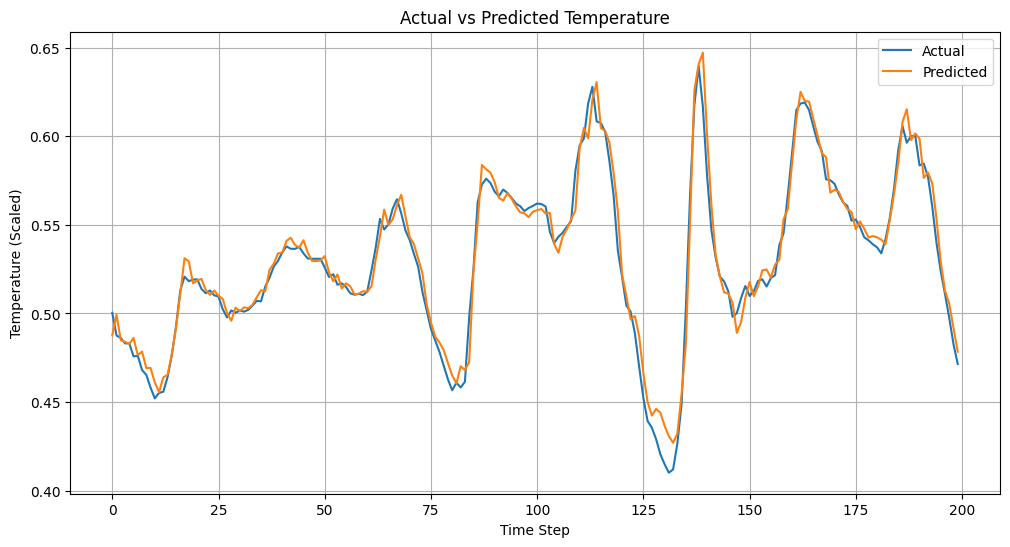

In [25]:
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# If y_pred has shape (n,1)
y_pred = y_pred.flatten()

plt.figure(figsize=(12,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Time Step')
plt.ylabel('Temperature (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# After training your LSTM:
y_pred_scaled = model.predict(X_test)

# Inverse transform to get real °C values
def inv_temp(arr_scaled, scaler, features, target_idx):
    dummy = np.zeros((len(arr_scaled), len(features)))
    dummy[:, target_idx] = arr_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

actual_temp    = inv_temp(y_test,       scaler, features, target_idx)
predicted_temp = inv_temp(y_pred_scaled, scaler, features, target_idx)

# Then compute metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(actual_temp, predicted_temp)
rmse = np.sqrt(mean_squared_error(actual_temp, predicted_temp))
print(f"MAE: {mae:.2f} °C | RMSE: {rmse:.2f} °C")

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE: 0.51 °C | RMSE: 0.71 °C
